Epoch   0 | Training Loss: 0.6757 | Validation Loss: 0.6369
Epoch 100 | Training Loss: 0.1888 | Validation Loss: 0.1683
Epoch 200 | Training Loss: 0.1405 | Validation Loss: 0.1379
Epoch 300 | Training Loss: 0.1307 | Validation Loss: 0.1399
Epoch 400 | Training Loss: 0.1237 | Validation Loss: 0.1417

Test Accuracy with L2 Regularization: 91.00%


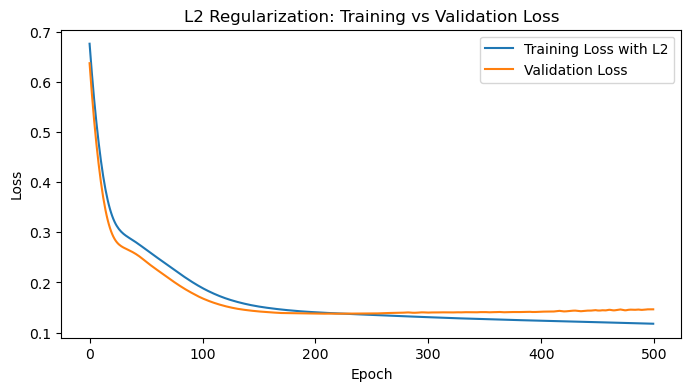

In [1]:
# L2 Regularization / Weight Decay Example in PyTorch

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
torch.manual_seed(0)

X, y = make_moons(n_samples=500, noise=0.25, random_state=0)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

num_epochs = 500

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()

    train_outputs = model(X_train)
    train_loss = loss_function(train_outputs, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Training Loss: {train_loss.item():.4f} | "
            f"Validation Loss: {val_loss.item():.4f}"
        )

model.eval()

with torch.no_grad():

    test_outputs = model(X_test)
    test_predictions = torch.argmax(test_outputs, dim=1)

    test_accuracy = (
        test_predictions == y_test
    ).float().mean() * 100

print(f"\nTest Accuracy with L2 Regularization: {test_accuracy:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training Loss with L2")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L2 Regularization: Training vs Validation Loss")
plt.legend()
plt.show()